# Fokker-Planck Equation & Diffusion Models

In modern generative models based on diffusion (such as **Score-Based Generative Models**), the process of adding noise and denoising is described by **Stochastic Differential Equations (SDEs)**.

The evolution of the probability distribution $p_t(x)$ of the data over time follows the **Fokker-Planck Equation (FPE)** corresponding to that SDE.

### 1. Forward SDE (Adding Noise)
Suppose we use a Variance Preserving (VP) SDE, which is equivalent to DDPM:
$$ dx = -\frac{1}{2}\beta(t) x dt + \sqrt{\beta(t)} dw $$

The corresponding Fokker-Planck Equation shows the evolution of the probability density $p_t(x)$:
$$ \frac{\partial p_t(x)}{\partial t} = \frac{\partial}{\partial x}\left[ \frac{1}{2}\beta(t) x p_t(x) \right] + \frac{1}{2}\beta(t) \frac{\partial^2}{\partial x^2} p_t(x) $$

### 2. Reverse SDE (Data Generation)
Anderson (1982) proved that the time-reversal of the above process is also a stochastic process and is described by another SDE:
$$ dx = \left[ -\frac{1}{2}\beta(t) x - \beta(t) \nabla_x \log p_t(x) \right] dt + \sqrt{\beta(t)} d\bar{w} $$

The core idea of Diffusion Models is to train a neural network $s_\theta(x, t) \approx \nabla_x \log p_t(x)$ (the Score function) to solve this reverse equation, transforming pure white noise into real data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

### Simulating the Forward Process
For simplicity, let's consider $\beta(t) = \beta = 1$. We will start with the data at $x_0 = 5$ (assuming our real data is a point mass at position 5).
Based on the analytical solution of the Fokker-Planck equation for the VP SDE, the distribution at time $t$ is a Gaussian distribution:
$$ p_t(x|x_0) = \mathcal{N}(x; x_0 e^{-t/2}, 1 - e^{-t}) $$

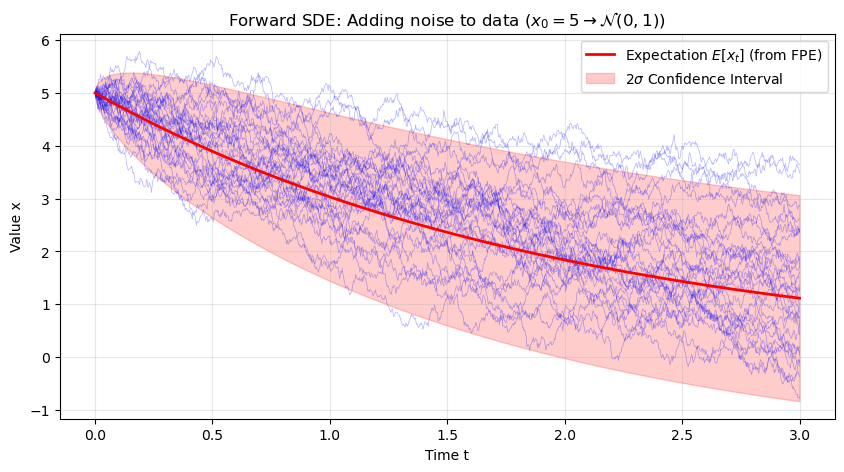

In [2]:
np.random.seed(42)

# Define parameters
beta = 1.0
x0 = 5.0
T = 3.0
N_steps = 1000
dt = T / N_steps
n_particles = 1000

# Initialize particles at x_0 = 5
x = np.full(n_particles, x0)
x_history = [x.copy()]

# Run Euler-Maruyama method for the Forward SDE
for i in range(N_steps):
    noise = np.random.randn(n_particles)
    dx = -0.5 * beta * x * dt + np.sqrt(beta * dt) * noise
    x = x + dx
    x_history.append(x.copy())

x_history = np.array(x_history)
t_grid = np.linspace(0, T, N_steps + 1)

# Visualize Forward SDE
plt.figure(figsize=(10, 5))
for i in range(30): # Plot trajectories of 30 representative particles
    plt.plot(t_grid, x_history[:, i], alpha=0.3, color='blue', linewidth=0.5)

# Plot the theoretical expectation from FPE
mean_analytical = x0 * np.exp(-0.5 * t_grid)
std_analytical = np.sqrt(1 - np.exp(-t_grid))
plt.plot(t_grid, mean_analytical, color='red', linewidth=2, label='Expectation $E[x_t]$ (from FPE)')
plt.fill_between(t_grid, mean_analytical - 2*std_analytical, mean_analytical + 2*std_analytical, color='red', alpha=0.2, label='2$\\sigma$ Confidence Interval')

plt.title('Forward SDE: Adding noise to data ($x_0 = 5 \\rightarrow \\mathcal{N}(0, 1)$)')
plt.xlabel('Time t')
plt.ylabel('Value x')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Simulating the Reverse Generative Process
In practice, we use a Neural Network (e.g., UNet) to estimate $\nabla_x \log p_t(x)$. 
However, in this simple example, since we know $p_t(x)$ is a Gaussian distribution by solving the Fokker-Planck equation above, we can calculate the exact score function (analytical score):
$$ \nabla_x \log p_t(x) = - \frac{x - x_0 e^{-t/2}}{1 - e^{-t}} $$

Now, we will start at $t = T$ with pure noise $x_T \sim \mathcal{N}(0,1)$ and use the Reverse SDE to run backwards in time to $t = 0$ to regenerate the original data.

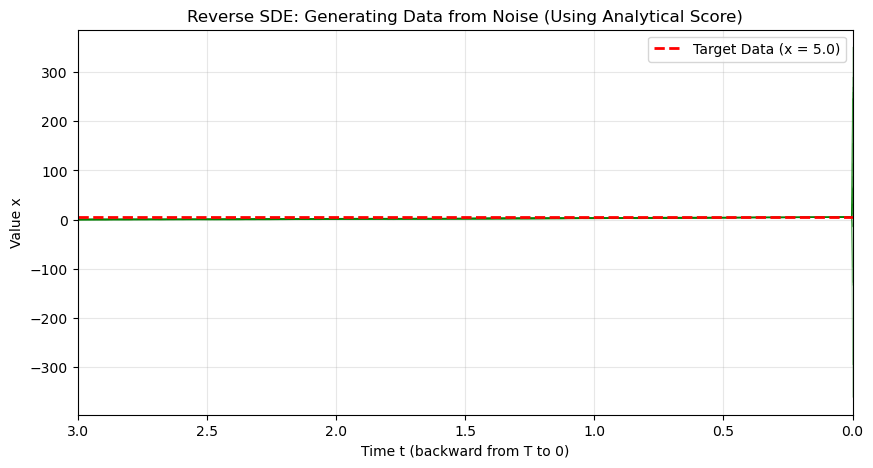

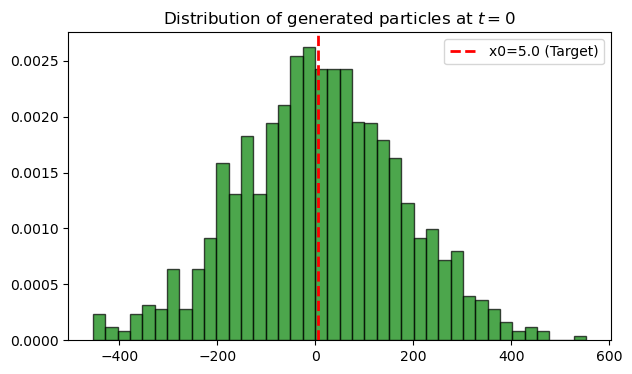

In [3]:
# Initialize starting state for the reverse process from pure noise (t=T)
x_rev = np.random.randn(n_particles)
x_rev_history = [x_rev.copy()]

# Define the Analytical Score function from the FPE solution
def analytical_score(x, t, x0):
    # Add a small epsilon to avoid division by zero when t -> 0
    variance = 1.0 - np.exp(-t) + 1e-6
    mean = x0 * np.exp(-0.5 * t)
    return -(x - mean) / variance

# Run Euler-Maruyama for Reverse SDE (Running backwards in time)
for i in range(N_steps - 1, -1, -1):
    t = t_grid[i]
    noise = np.random.randn(n_particles)
    
    # Calculate drift of Reverse SDE
    score = analytical_score(x_rev, t, x0)
    drift = -0.5 * beta * x_rev - beta * score
    
    # Update dx (Going backward from T to 0, which means dt is negative -> x_{t-dt} = x_t - drift*dt + noise)
    x_rev = x_rev - drift * dt + np.sqrt(beta * dt) * noise
    x_rev_history.append(x_rev.copy())

x_rev_history = np.array(x_rev_history)
t_rev_grid = np.linspace(T, 0, N_steps + 1)

# Visualize Reverse SDE
plt.figure(figsize=(10, 5))
for i in range(30):
    plt.plot(t_rev_grid, x_rev_history[:, i], alpha=0.3, color='green', linewidth=0.5)

plt.title('Reverse SDE: Generating Data from Noise (Using Analytical Score)')
plt.xlabel('Time t (backward from T to 0)')
plt.ylabel('Value x')
plt.xlim(T, 0)  # Reverse X-axis to clearly show backward process

plt.axhline(y=x0, color='red', linestyle='--', linewidth=2, label=f'Target Data (x = {x0})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Check the distribution of generated data points at t=0
plt.figure(figsize=(7, 4))
plt.hist(x_rev_history[-1, :], bins=40, density=True, color='green', alpha=0.7, edgecolor='black')
plt.axvline(x=x0, color='red', linestyle='dashed', linewidth=2, label=f'x0={x0} (Target)')
plt.title('Distribution of generated particles at $t=0$')
plt.legend()
plt.show()